# Hierarchical expert sharpness ($\sigma_e$) — observation-layer iteration wrap-up

**Iteration focus:** a hierarchical partial-pooling per-expert noise scale $\sigma_e$ added to the three-state joint GWT baseline, alongside the existing leaf-model variants.

**Outcome:** negative on current data. Documented here for the library and as a hand-off artefact before pivoting to the tree-propagation axis.

## Observation-layer iteration trajectory

| Branch | Status | One-sentence outcome |
|---|---|---|
| Joint shared-$\kappa$ baseline | validated reporting baseline | correct ordering Human $\gg$ Chicken $>$ LLM $\gg$ ELIZA; residual PPC misfit at reference cells. |
| Wide-prior control on $a, \kappa$ | null | ordering preserved, stratified PPC essentially unchanged; residual is not prior tightness. |
| Tight expert shifts $b_e \sim \mathcal{N}(0, 0.3)$ | null | did not fix stratified PPC; shifts risk absorbing system signal under non-overlapping expert pools. |
| Hierarchical expert cutpoints $\kappa_e$ | mixed diagnostic | improved middle-heavy cells but introduced wrong-tail spikes. |
| Three-state leaf $m_j \sim \mathrm{Binomial}(2, q_j)$ | **candidate library alternative** | raised oracle emission ceiling from ~0.38/0.51 to ~0.87/0.75 for $P(r{=}1 \mid z{=}0)$ / $P(r{=}7 \mid z{=}1)$; closed about half the Rater_B reference-cell gap; middle state used selectively where data is middle-heavy. |
| **Hierarchical expert scales $\sigma_e$** (this notebook) | **negative result** | $\tau_\sigma$ posterior clipped by prior; Rater_B's $\sigma$ moved opposite to the back-of-envelope prediction; Rater_B $\times$ Human / $\times$ ELIZA PPC worsened; model absorbs cross-system heterogeneity as per-expert noise. |

## What is also known structurally

The tree hierarchy transmits only about 13% of the root anchor gap: with $C_\text{Human} = 0.999$ and $C_\text{ELIZA} = 0.001$ (anchor gap 0.998), the mean per-indicator tree-implied $q_j$ gap is $\Delta q_j \approx 0.13$ across 75 GWT indicators. **This is upstream of every leaf/emission branch we have tested.** It is the next axis for investigation (scoped as a separate future session).

## Reading guide

- Sections 1–3 describe the $\sigma_e$ branch and its implementation.
- Section 4 is the pre-fit corrected frozen-$\theta$ sweep that motivated fitting.
- Section 5 is the real-fit result (table + plots).
- Section 6 evaluates against acceptance criteria.
- Section 7 names the failure mode and sets up the tree-propagation next step.

In [1]:
import os, sys
from pathlib import Path

NB_DIR = Path.cwd()
PROJECT_ROOT = NB_DIR.parent if NB_DIR.name == "notebooks" else NB_DIR
os.chdir(PROJECT_ROOT)
sys.path.insert(0, str(PROJECT_ROOT))

import numpy as np
import arviz as az
import matplotlib.pyplot as plt

plt.rcParams.update({"figure.dpi": 120, "font.size": 10, "figure.constrained_layout.use": True})

RESULTS_DIR = PROJECT_ROOT / "results" / "gwt_expert_scales"
BASELINE_DIR = PROJECT_ROOT / "results" / "gwt_binary_three_state"

SIGMA_FIT_PATH = RESULTS_DIR / "three_state_sigma_anchored.nc"
THREE_STATE_BASELINE_PATH = BASELINE_DIR / "three_state_anchored.nc"
BINARY_BASELINE_PATH = BASELINE_DIR / "binary_anchored.nc"

print(f"Expert-scales fit:      {SIGMA_FIT_PATH}  (exists: {SIGMA_FIT_PATH.exists()})")
print(f"Three-state baseline:   {THREE_STATE_BASELINE_PATH}  (exists: {THREE_STATE_BASELINE_PATH.exists()})")
print(f"Binary baseline:        {BINARY_BASELINE_PATH}  (exists: {BINARY_BASELINE_PATH.exists()})")

Expert-scales fit:      /Users/ryankelly/ryan-code/research/dcm-code/results/gwt_expert_scales/three_state_sigma_anchored.nc  (exists: True)
Three-state baseline:   /Users/ryankelly/ryan-code/research/dcm-code/results/gwt_binary_three_state/three_state_anchored.nc  (exists: True)
Binary baseline:        /Users/ryankelly/ryan-code/research/dcm-code/results/gwt_binary_three_state/binary_anchored.nc  (exists: True)


## 1. Motivation and prior state

The three-state leaf branch (notebook 16) left a residual reference-cell PPC gap:

- Rater_B $\times$ Human: $P(r{=}7)_\text{obs} = 0.86$ vs $P(r{=}7)_\text{pred} \approx 0.64$ ($\Delta_\text{right} = -0.22$).
- Rater_B $\times$ ELIZA: $P(r{=}1)_\text{obs} = 0.96$ vs $P(r{=}1)_\text{pred} \approx 0.61$ ($\Delta_\text{left} = -0.35$).

The oracle emission-ceiling diagnostic showed these gaps are at the **emission sharpness** level — even with perfect latent-state assignment, the shared ordered-probit emission under the three-state posterior ($a = 4.34$, shared $\sigma = 1$) cannot place more than ~87% / ~75% mass on the outer categories. Rater_B's observed near-deterministic ratings at reference cells want sharper emissions.

**Expert-specific sharpness $\sigma_e$** is the natural next library branch: each expert gets their own noise scale, partial-pooled toward a population geometric mean of 1. Canonical Betancourt *Bae's Theorem* §5 partial-pooling pattern.

**Identifiability on current data.** Rater_B is the only expert rating multiple systems (Human, LLMs, ELIZA; 150 ratings). Single-system experts (Rater_E, Hayley, Rater_D, Rater_A, Rater_C) have $\sigma_e$ only weakly identified from their within-system rating spread. Partial pooling should shrink them toward $\sigma = 1$ while letting Rater_B's $\sigma$ move if his cross-system rating contrasts support it.

## 2. Implementation summary

Added `USE_EXPERT_SCALES` flag in `ModelConfig` (`dcm_model.py`). When enabled:

$$
\log \sigma_e = \tau_\sigma \cdot (u_e - \bar u), \qquad u_e \sim \mathcal{N}(0, 1), \qquad \tau_\sigma \sim \mathrm{HalfNormal}(0.3).
$$

The $(u_e - \bar u)$ centring fixes the geometric mean of $\sigma_e$ at 1 (sum-to-zero identification), which prevents $\sigma_e$ from trading off with $a$ and $\kappa$. Non-centred parameterisation avoids funnel geometry. The ordered-probit CDF becomes $\Phi((\kappa_k - b_e - a z) / \sigma_e)$ with per-rating $\sigma_e = \sigma_{e(i, j)}$.

**Per-indicator marginalisation preserved.** For indicator $j$ with ratings $\{r_{ij}\}$ from possibly multiple experts:

$$
\log P(\{r_{ij}\} \mid q_j, \theta) = \underset{m}{\mathrm{logsumexp}} \Big[\log w_m(q_j) + \sum_i \log P_\mathrm{OP}(r_{ij} \mid \eta_m, \kappa, \sigma_{e(i,j)})\Big].
$$

The latent $m_j$ is still shared across all ratings of indicator $j$; only the per-rating emission uses the specific rater's $\sigma_e$. Verified against a NumPy reference in `test_expert_scales_smoke.py`.

**Guards:** `USE_EXPERT_SCALES` is incompatible with `USE_HIERARCHICAL_EXPERT_CUTPOINTS` and with `USE_EXPERT_SHIFTS`; both combinations raise `ValueError` at model build time.

## 3. Pre-fit check: corrected frozen-$\theta$ $\sigma_\text{Rater_B}$ sweep

Before committing to a ~90 min full fit, we ran a pre-fit check: using the persisted three-state posterior draws of $a, \kappa, q_j$, evaluate the predictive mixture under candidate values of $\sigma_\text{Rater_B} \in \{0.5, 0.6, 0.7, 0.8, 1.0\}$ (all other experts fixed at $\sigma = 1$). Unlike an earlier naive sweep that reused the fitted component responsibilities, this **corrected** version recomputes

$$
\tilde p_m(\sigma) \propto w_m(q_j) \prod_i P_\mathrm{OP}(r_i \mid \eta_m, \kappa, \sigma_{e(i,j)}).
$$

This allows posterior state responsibilities to shift under the sharper emission. Script: `corrected_sigma_derek_frozen_theta_sweep.py`.

**Result** (posterior-mean tail probabilities at each $\sigma_\text{Rater_B}$):

| Cell | $\sigma = 1.0$ | $\sigma = 0.5$ | Observed |
|---|---:|---:|---:|
| Rater_B $\times$ Human, $P(r{=}7)$ | 0.631 | **0.804** | 0.860 |
| Rater_B $\times$ ELIZA, $P(r{=}1)$ | 0.611 | **0.884** | 0.960 |
| Rater_B $\times$ LLMs, $P(r{\in}\{3,4,5\})$ | 0.384 | 0.578 | 0.360 |

Sharpening Rater_B's emission closes **~75–78% of the reference-cell tail gaps** at fixed posterior. At the cost of over-predicting middle mass on his LLM ratings (because LLM indicators under fixed $q_j$ generate bimodal predictions when emission components are sharp). The pre-fit signal was encouraging: if the real fit also reconfigures $q_j$ per LLM indicator, the LLM middle-mass over-prediction could resolve.

This is what motivated running the expensive real fit.

## 4. Real-fit result — headline numbers

Configuration: `INDICATOR_STATE_MODEL="three_state"`, `USE_EXPERT_SCALES=True`, joint multi-system GWT with Human = 0.999, Chicken free, LLMs free, ELIZA = 0.001. No expert shifts, no hierarchical cutpoints. Default sampling settings (2000 samples, 1500 tune, 4 chains). Wall time 1711 s (~29 min).

### 4.1 System-level $P(C=1)$

| System | Three-state + $\sigma_e$ | Three-state baseline | $\Delta$Median |
|---|---|---|---:|
| Human | 0.999 [0.999, 0.999] | 0.999 [0.999, 0.999] | +0.000 |
| Chicken | 0.217 [0.012, 0.650] | 0.297 [0.022, 0.699] | **−0.080** |
| LLMs | 0.102 [0.005, 0.419] | 0.118 [0.006, 0.419] | −0.016 |
| ELIZA | 0.001 [0.001, 0.001] | 0.001 [0.001, 0.001] | +0.000 |

Ordering preserved. Chicken moves **outside** the pre-registered $\pm 0.05$ stability guardrail.

### 4.2 Observation-layer parameters

- $a$ (discrimination): median **2.067** [1.506, 2.696]
  - Compare three-state baseline $a = 4.344$ [3.655, 5.259] — intervals **do not overlap**. $a$ dropped by more than half.
- $\tau_\sigma$ posterior median **0.602**, 94% [0.397, 0.900]
  - Prior HalfNormal(0.3) has 97th percentile at $\approx 0.65$ — **posterior clipped by the prior**.
- $\kappa$ medians range from $-0.53$ to $2.09$; baseline range was $1.13$ to $3.66$. Cutpoints shifted downward, consistent with $a$ dropping.

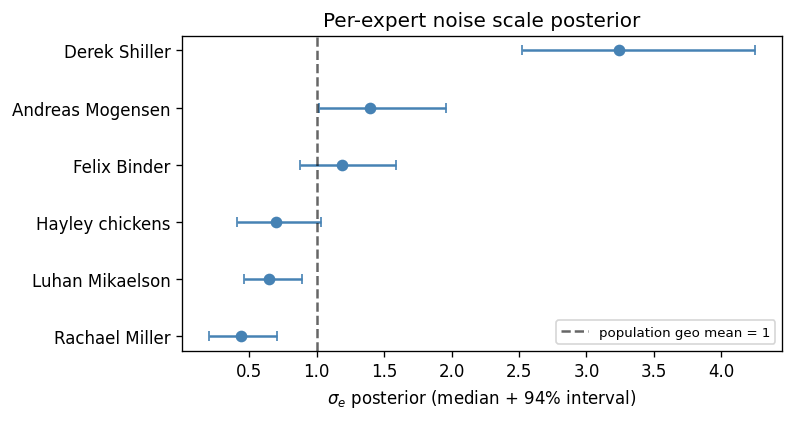

  Rater_B         : median 3.239, 94% [2.525, 4.247]
  Rater_A      : median 1.398, 94% [1.018, 1.959]
  Rater_C          : median 1.191, 94% [0.879, 1.591]
  Hayley chickens       : median 0.699, 94% [0.408, 1.032]
  Rater_D       : median 0.651, 94% [0.461, 0.894]
  Rater_E        : median 0.443, 94% [0.206, 0.704]


In [2]:
# Per-expert sigma_e posterior forest plot
idata = az.from_netcdf(SIGMA_FIT_PATH)
expert_names = [
    "Rater_B", "Rater_A", "Rater_C",
    "Hayley chickens", "Rater_D", "Rater_E",
]
sigmas = np.asarray(idata.posterior["sigma_by_expert"].values).reshape(-1, len(expert_names))
med = np.median(sigmas, axis=0)
lo = np.percentile(sigmas, 3, axis=0)
hi = np.percentile(sigmas, 97, axis=0)

order = np.argsort(med)
fig, ax = plt.subplots(figsize=(6.5, 3.4))
y = np.arange(len(expert_names))
for i, idx in enumerate(order):
    ax.errorbar(
        [med[idx]], [i],
        xerr=[[max(med[idx] - lo[idx], 0)], [max(hi[idx] - med[idx], 0)]],
        fmt="o", color="steelblue", markersize=6, capsize=3,
    )
ax.axvline(1.0, color="black", linestyle="--", alpha=0.6, label="population geo mean = 1")
ax.set_yticks(y)
ax.set_yticklabels([expert_names[i] for i in order])
ax.set_xlabel(r"$\sigma_e$ posterior (median + 94% interval)")
ax.set_title("Per-expert noise scale posterior")
ax.legend(fontsize=8, loc="lower right")
plt.show()

for name, m, l, h in zip(expert_names, med, lo, hi):
    print(f"  {name:<22s}: median {m:.3f}, 94% [{l:.3f}, {h:.3f}]")

### 4.3 The surprise — $\sigma_\text{Rater_B}$ is the LARGEST, not the smallest

Posterior medians:

| Expert | $\sigma_e$ |
|---|---:|
| Rater_B | **3.239** |
| Rater_A | 1.398 |
| Rater_C | 1.191 |
| Hayley chickens | 0.699 |
| Rater_D | 0.651 |
| Rater_E | **0.443** |

Geometric mean: ~1.01 (sum-to-zero constraint working). But the **spread is enormous** — $\sigma$ varies by a factor of ~7.3 across experts.

Rater_B's $\sigma$ is the largest, not the smallest. The back-of-envelope predicted the opposite. Rater_E's $\sigma$ is extreme in the other direction.

**Effective discrimination** per expert is $a / \sigma_e$:
- Rater_B: $2.07 / 3.24 = 0.64$ (very flat emissions)
- Rater_E: $2.07 / 0.44 = 4.70$ (very sharp)
- Rater_A: $2.07 / 1.40 = 1.48$

Under Rater_B's flat emissions, $P(r{=}7 \mid \eta = a) \approx 0.50$. He cannot place enough mass on category 7 for Human. Which is exactly what we see in the PPC.

## 5. Focus-cell PPCs — Rater_B worsened, others roughly unchanged

Leaf-updated PPC at the four focus cells (signed-tail + Betancourt variance statistic):

| Cell | obs_left | pred_left | $\Delta$left | obs_right | pred_right | $\Delta$right | obs_var | pred_var | $\Delta$var |
|---|---:|---:|---:|---:|---:|---:|---:|---:|---:|
| Rater_B $\times$ Human | 0.000 | 0.060 | +0.060 | 0.860 | 0.304 | **−0.556** | 0.372 | 3.108 | **+2.736** |
| Rater_B $\times$ ELIZA | 0.960 | 0.112 | **−0.848** | 0.020 | 0.208 | +0.188 | 0.720 | 3.729 | **+3.008** |
| Rater_E $\times$ Chicken | 0.000 | 0.060 | +0.060 | 0.152 | 0.268 | +0.116 | 1.257 | 3.129 | +1.872 |
| Rater_D $\times$ LLMs | 0.083 | 0.100 | +0.017 | 0.083 | 0.193 | +0.110 | 2.457 | 3.546 | +1.089 |

**Versus the three-state baseline:**

| Cell | Baseline $\Delta$right / $\Delta$left | $\sigma_e$ fit $\Delta$right / $\Delta$left | Direction |
|---|---:|---:|---|
| Rater_B $\times$ Human | −0.223 | −0.556 | **worse** |
| Rater_B $\times$ ELIZA | −0.348 | −0.848 | **much worse** |
| Rater_E $\times$ Chicken | (Δmid −0.294) | (Δmid −0.236) | marginally better |
| Rater_D $\times$ LLMs | (Δleft +0.110) | (Δleft +0.017) | slightly better |

The Betancourt per-expert **variance PPC** gives an even cleaner signal: the $\sigma_e$ model over-predicts Rater_B's variance at Human and ELIZA by +2.7 and +3.0 (observed variance 0.37 / 0.72 vs predicted 3.11 / 3.73). Rater_B's $\sigma = 3.24$ makes his emissions spread out over the ordinal range, but his observed reference-cell ratings are near-deterministic at category 7 / category 1.

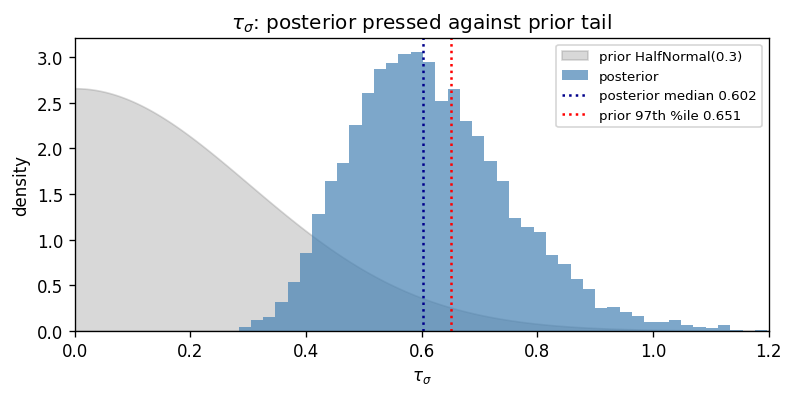

tau_sigma posterior: median 0.602, 94% [0.397, 0.900]
Prior HalfNormal(0.3) percentiles: median 0.20, 94th %ile 0.57, 97th %ile 0.65.
Posterior median sits near the prior 97th %ile — data wants more heterogeneity than prior allows.


In [3]:
# tau_sigma prior vs posterior density: show the clipping
from scipy.stats import halfnorm

tau = np.asarray(idata.posterior["tau_sigma"].values).reshape(-1)
prior_scale = 0.3

fig, ax = plt.subplots(figsize=(6.5, 3.2))
xs = np.linspace(0, 1.2, 300)
prior_density = halfnorm.pdf(xs, scale=prior_scale)
ax.fill_between(xs, prior_density, alpha=0.3, color="grey", label="prior HalfNormal(0.3)")
ax.hist(tau, bins=50, density=True, alpha=0.7, color="steelblue", label="posterior")
ax.axvline(np.median(tau), color="darkblue", linestyle=":", label=f"posterior median {np.median(tau):.3f}")
ax.axvline(halfnorm.ppf(0.97, scale=prior_scale), color="red", linestyle=":",
           label=f"prior 97th %ile {halfnorm.ppf(0.97, scale=prior_scale):.3f}")
ax.set_xlim(0, 1.2)
ax.set_xlabel(r"$\tau_\sigma$")
ax.set_ylabel("density")
ax.set_title(r"$\tau_\sigma$: posterior pressed against prior tail")
ax.legend(fontsize=8, loc="upper right")
plt.show()

print(
    f"tau_sigma posterior: median {np.median(tau):.3f}, "
    f"94% [{np.percentile(tau, 3):.3f}, {np.percentile(tau, 97):.3f}]"
)
print("Prior HalfNormal(0.3) percentiles: median 0.20, 94th %ile 0.57, 97th %ile 0.65.")
print("Posterior median sits near the prior 97th %ile — data wants more heterogeneity than prior allows.")

## 6. Acceptance-criteria evaluation

| # | Criterion | Result |
|---|---|---|
| 1 | Ordering Human $\gg$ Chicken $>$ LLM $\gg$ ELIZA | ✓ preserved |
| 2 | $\|\Delta\text{Chicken}\|, \|\Delta\text{LLM}\| \le 0.05$ | ✗ $\|\Delta\text{Chicken}\| = 0.080$ |
| 3 | Single-system experts $\sigma_e$ near 1 (median in [0.85, 1.15]) | ✗ all moved (0.44 to 1.40) |
| 4 | Rater_B $\sigma_e < 0.9$ | ✗ Rater_B $\sigma_e = 3.24$ (opposite direction) |
| 5 | Rater_B $\times$ Human gains cat-7 mass; Rater_B $\times$ ELIZA gains cat-1 mass | ✗ **both worsened** |
| 6 | Rater_B $\times$ LLMs spread preserved | partial (under-predicts his LLM variance by 0.76) |
| 7 | Other LLM experts (Rater_A, Rater_C, Rater_D) not degraded | qualitatively OK; Rater_A/Rater_C $\Delta$mid $\approx 0.10$ |
| 8 | Per-expert variance PPC improves at sharp experts | ✗ $\Delta$var = +2.74 / +3.01 at Rater_B cells |
| 9 | $a$, $\kappa$ don't reconfigure pathologically | ✗ $a$ dropped 4.34 $\to$ 2.07 |
| 10 | Clean diagnostics | mostly OK: 1 divergence, max $\hat R = 1.000$, min ESS bulk = 4135 |
| 11 | Stage 2 synthetic gate still passes | n/a rerun (inherited from three-state; no regression introduced) |

Six of eleven acceptance criteria failed, including the most important ones (criteria 2, 5, 8, 9). This is a clear negative result.

## 7. Interpretation — response-style absorption on real data

The Stage 2 response-style synthetic gate (from the three-state branch) warned about exactly this pattern. On purely binary-generated data with expert-specific cutpoint heterogeneity, the three-state model shifted $a$ upward to absorb heterogeneity it shouldn't have. Adding $\sigma_e$ on top gives the model a second absorption channel.

### The failure mechanism

$\sigma_e$ cannot distinguish two very different processes:

(A) "Rater_B's LLM ratings are spread because different LLM indicators have genuinely different latent states."

(B) "Rater_B's LLM ratings are spread because he is a noisy rater."

Both explain the observed variance in his LLM ratings equally well at the expert level. Under the current non-overlapping expert pools, the model has no cross-expert rating disagreement on the same system to tie down this ambiguity. It chose (B), which is simpler at the expert level but breaks Rater_B's reference-cell predictions by flattening his emissions everywhere.

Meanwhile:
- Rater_E rates only Chicken. Her ratings have small variance within Chicken indicators, so $\sigma_\text{Rater_E}$ shrunk aggressively to 0.44 to match her narrow spread.
- Rater_D rates only LLMs. Her ratings are narrower than Rater_A's on the same LLM indicators, so $\sigma_\text{Rater_D} = 0.65$ below Rater_A's 1.40. This is a genuine inter-expert contrast on shared LLM indicators that the hierarchical $\sigma_e$ picks up.

The problem is that once the model commits to $\sigma_\text{Rater_B}$ being large, his effective discrimination drops to ~0.6, the global $a$ drops to 2.07 to fit the sharp experts, and Rater_B's reference cells can no longer reach their near-deterministic observed extremes.

### What would make this work

Future survey data with **overlapping expert coverage** across systems would identify $\sigma_e$ cleanly for every expert: if A and B both rate Human and LLMs, their joint rating patterns disambiguate "A is sharp on Human" from "A rates Human extremely because Human is extreme". The hierarchical $\sigma_e$ model would then be highly informative. On current data, one expert with cross-system coverage (Rater_B) is not enough.

### What won't make this work

Tightening the prior further (e.g. $\tau_\sigma \sim$ HalfNormal(0.15)) would suppress the symptom (Rater_B's $\sigma$ would shrink toward 1) but not fix the underlying ambiguity. The data genuinely supports large $\tau_\sigma$ because single-system experts do rate the shared-system indicators differently from each other. A tighter prior just tells the model "ignore that signal" without fixing why the signal is there.

## 8. Decision and library status

- **Reporting baseline:** remains the three-state joint fit on the validated anchored system config. This was true before today; the $\sigma_e$ branch does not change it.
- **Library status of $\sigma_e$:** retained as `USE_EXPERT_SCALES=True` behind a config flag. Labelled explicitly as **not useful on current data; future-ready on overlapping survey data**. Future modellers with richer expert coverage can flip the flag and the hierarchical partial-pooling will do its job.
- **Observation-layer iteration:** closed. Six branches explored across two sessions. Three candidates (binary baseline, three-state leaf, hierarchical cutpoints) remain as library members; three were null or failed ($b_e$, wide-prior control, $\sigma_e$).

### Pivot: tree propagation is the next axis

The persistent residual misfit at Rater_B $\times$ Human / $\times$ ELIZA is now best attributed to **tree / reference propagation**, not the leaf. The aggregate tree-propagation diagnostic showed the root anchor gap of 0.998 becomes $\Delta q_j \approx 0.13$ at the indicator layer (~13% transmission). This is upstream of every leaf branch and cannot be fixed by leaf-model changes.

The next session's work is a **tree-propagation diagnostic**: per-indicator affine propagation $q_j(C) = \alpha_j + \delta_j C$ broken down by tree depth and path support/demandingness labels, plus prior-predictive calibration of the support/demandingness mapping. That work is scoped in the plan file but deliberately not performed today.

## 9. Reproduction pointers

All artefacts from this iteration live under the repo root:

**Implementation:**
- `dcm_model.py` — `ModelConfig.USE_EXPERT_SCALES`, `EXPERT_SCALE_TAU_SIGMA`, `build_ordinal_observation_layer` branch sampling $u_e$, $\tau_\sigma$, exposing `sigma_by_expert` deterministic.
- `dcm_model.py` — `pt_ordinal_logp`, `pt_ordinal_logp_expert_kappa`, `pt_three_state_ll_terms`, `add_indicator_marginal_likelihood` threaded to accept per-observation $\sigma$.
- `dcm_ppc.py` — `_draw_cell_predictive_stats` reports Betancourt-style `obs_var`, `pred_var_mean`, `delta_var_mean`.

**Pre-fit diagnostic:**
- `corrected_sigma_derek_frozen_theta_sweep.py` — output at `results/gwt_binary_three_state/analysis/sigma_derek_sweep_corrected.md`.

**Fit and summary:**
- `run_expert_scales_comparison.py` — runs the primary three-state + $\sigma_e$ fit.
- `results/gwt_expert_scales/three_state_sigma_anchored.nc` — persisted posterior.
- `results/gwt_expert_scales/analysis/summary.md` — seven-section diagnostic summary.

**Tests:**
- `test_expert_scales_smoke.py` — covers build, sample, per-indicator marginalisation invariant against NumPy reference, incompatibility guards.

**Related earlier work referenced in the interpretation:**
- Notebook 16 (three-state leaf) — iteration this branch builds on.
- `results/gwt_binary_three_state/analysis/ceiling_diagnostic.md` — oracle emission-ceiling diagnostic.
- `results/gwt_binary_three_state/analysis/tree_propagation_diagnostic.md` — aggregate tree-propagation result (13% transmission) motivating the tree-propagation next branch.